In [1]:
import numpy as np
import spacy
import pandas as pd
import gensim.downloader as api

In [2]:
wv = api.load("word2vec-google-news-300")

In [3]:
wv.similarity(w1 = "great", w2 = "good")

np.float32(0.729151)

In [4]:
wv_great = wv["great"]
wv_good = wv["good"]

In [5]:
df = pd.read_csv("fake_and_real_news.csv")

In [6]:
df

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real
...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake
9896,Trump consults Republican senators on Fed chie...,Real
9897,Trump lawyers say judge lacks jurisdiction for...,Real
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake


In [7]:
df.label.value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

In [8]:
df["label_num"] = df["label"].map({"Fake": 0, "Real": 1})

In [9]:
df

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1
...,...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake,0
9896,Trump consults Republican senators on Fed chie...,Real,1
9897,Trump lawyers say judge lacks jurisdiction for...,Real,1
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake,0


In [10]:
nlp = spacy.load("en_core_web_lg")

def preprocess_and_vectorize(text):
    doc = nlp(text)
    
    filtered_vectors = []
    for token in doc:
        if token.is_punct or token.is_stop:
            continue
        
        if token.has_vector: 
            filtered_vectors.append(token.vector)

    if not filtered_vectors:
        return np.zeros(300)
        
    return np.mean(filtered_vectors, axis=0)

In [11]:
preprocess_and_vectorize("Don't worrying if you don't understand")

array([-3.17919999e-01,  7.80950040e-02, -3.48030001e-01,  3.42649482e-02,
       -7.07469955e-02,  5.01822010e-02,  2.14084998e-01, -4.53440025e-02,
       -1.34985000e-02,  2.43505001e+00, -3.64165008e-01,  6.18144982e-02,
       -2.45799981e-02, -1.22050047e-02, -1.96192503e-01, -8.97229984e-02,
       -1.57059997e-01,  6.02490008e-01, -3.19792509e-01,  1.34594992e-01,
        1.36775002e-01, -9.94450077e-02,  1.50516510e-01, -6.18125014e-02,
       -1.39394507e-01, -1.19554996e-02,  1.38637006e-01, -1.25072002e-01,
        2.01240003e-01, -3.44574988e-01, -3.13279986e-01,  2.08400503e-01,
       -1.96250007e-02, -5.16720004e-02,  1.47982046e-01,  3.33815008e-01,
        4.27264988e-01,  2.31885001e-01,  4.50800061e-02,  3.35600004e-02,
        4.67559993e-02, -3.55590016e-01, -2.33199000e-01,  2.68875539e-01,
        8.08970034e-02,  7.07859993e-02, -1.44409999e-01,  4.74559981e-03,
        7.38318115e-02, -6.67700022e-02, -2.08940506e-01,  4.13364992e-02,
       -9.70190018e-02, -

In [12]:
wv.get_mean_vector(["worry", "understand"]).shape

(300,)

In [13]:
v1 = wv["worry"]
v2 = wv["understand"]

np.mean([v1,v2], axis = 0).shape

(300,)

In [14]:
df["vector"] = df["Text"].apply(lambda text: preprocess_and_vectorize(text))

In [15]:
df

,Text,label,label_num,vector
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.22315274, 0.12317936, -0.004302724, 0.0171..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.040695958, 0.13872455, 0.041955817, 0.0797..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.23661754, 0.14024854, 0.11014857, -0.07688..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.06560863, 0.06451181, 0.1734452, -0.023986..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.092378974, 0.031730585, 0.11355723, 0.0230..."
...,...,...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake,0,"[-0.14201885, 0.10646902, -0.019194089, 0.0617..."
9896,Trump consults Republican senators on Fed chie...,Real,1,"[-0.13562262, 0.14615923, 0.15046674, 0.005634..."
9897,Trump lawyers say judge lacks jurisdiction for...,Real,1,"[-0.15839784, 0.09612805, 0.08288505, -0.03586..."
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake,0,"[-0.10913202, 0.20312065, -0.00605867, -0.0545..."


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size = 0.2,
    random_state = 2022,
    stratify = df.label_num
)

In [18]:
print(f"Shape of x_train before reshaping :- {x_train.shape}")
print(f"Shape of x_test before reshaping :- {x_test.shape}")

x_train_2d = np.stack(x_train)
x_test_2d = np.stack(x_test)

print(f"Shape of x_train after reshaping :- {x_train_2d.shape}")
print(f"Shape of x_test after reshaping :- {x_test_2d.shape}")

Shape of x_train before reshaping :- (7920,)
Shape of x_test before reshaping :- (1980,)
Shape of x_train after reshaping :- (7920, 300)
Shape of x_test after reshaping :- (1980, 300)


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

clf = GradientBoostingClassifier()

clf.fit(x_train_2d, y_train)

y_pred = clf.predict(x_test_2d)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1000
           1       0.97      0.98      0.97       980

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



In [20]:
test_news = [
    "Trump proposes U.S. tax overhaul, stirs concerns on deficit WASHINGTON (Reuters) - President Donald Trump proposed on Wednesday the biggest U.S. tax overhaul in three decades, calling for tax cuts for most Americans, but prompting criticism that the plan favors business and the rich and could add trillions of dollars to the deficit. The proposal drew a swift, skeptical response from Senator Bob Corker, a leading Republican “fiscal hawk,” who vowed not to vote for any federal tax package financed with borrowed money. “What I can tell you is that I’m not about to vote for any bill that increases our deficit, period,” Corker, who said on Tuesday he would not seek re-election in 2018, told reporters. Trump said his tax plan was aimed at helping working people, creating jobs and making the tax code simpler and fairer. But it faces an uphill battle in the U.S. Congress with Trump’s own Republican Party divided over it and Democrats hostile. The plan would lower corporate and small-business income tax rates, reduce the top income tax rate for high-earning American individuals and scrap some popular tax breaks, including one that benefits people in high-tax states dominated by Democrats. Forged during months of talks among Trump’s aides and top congressional Republicans, the plan contained few details on how to pay for the tax cuts without expanding the budget deficit and adding to the nation’s $20 trillion national debt. The plan still must be turned into legislation, which was not expected until after Congress makes progress on the fiscal 2018 budget, perhaps in October. It must then be debated by the Republican-led congressional tax-writing committees. Analysts were skeptical that Congress could approve a tax bill this year, but that is what Republicans hope to achieve so they can enter next year’s congressional election campaigns with at least one legislative achievement to show for 2017. Financial markets rallied on the plan’s unveiling, an event long anticipated by traders betting that stocks would benefit from both faster economic growth and inflation. At an event in Indianapolis, Trump called the plan the largest tax cut in U.S. history. “We want tax reform that is pro-growth, pro-jobs, pro-worker, pro-family and, yes, tax reform that is pro-American,” he said. The real estate mogul-turned-politician, who promised big tax cuts as a candidate, told reporters he personally would not gain financially from the proposal. “I think there’s very little benefit for people of wealth,” said Trump, who unlike many of his White House predecessors, has refused to make public his own tax returns. Republicans have produced no major legislative successes since Trump took office in January, even though they control the White House and both chambers of Congress. Their top legislative priority, overhauling the U.S. healthcare system, collapsed again in the Senate on Tuesday. A comprehensive rewrite of the U.S. tax code has eluded previous presidents and Congress for decades. The last one was passed in 1986 under Republican President Ronald Reagan. Trump’s plan falls short of the sweeping, bipartisan package crafted by Reagan and congressional Democrats, analysts said. The White House said that, under the proposal, typical middle-class families would have less income subject to federal tax. Trump said the first $12,000 earned by an individual and the first $24,000 by a married couple would be tax-free. The plan would lower the top individual tax rate, paid by the nation’s top earners, to 35 percent from 39.6 percent. It would lower the top corporate income tax rate to 20 percent from the current 35 percent. The existing rate is high globally, but many U.S.-based multinationals pay much less than the headline rate because of abundant loopholes and tax breaks. Trump has appealed to Democrats to back the plan, although they were not consulted in drafting it. Republicans hold a thin 52-48 Senate majority and may need some Democratic support to win passage. But Democrats said the plan would expand the federal deficit in order to deliver tax cuts to wealthy Americans rather than the middle-class families that Trump and Republicans say they are trying to help.  “If this framework is all about the middle class, then Trump Tower is middle-class housing,” said Senator Ron Wyden, the top Democrat on the tax law-writing Senate Finance Committee.      Republican Kevin Brady, chairman of the tax-writing House of Representatives Ways and Means Committee, said he expected tax legislation to be passed by the end of this year. The Committee for a Responsible Federal Budget, a Washington-based policy group, estimated on Wednesday the plan contained about $5.8 trillion of total tax cuts over a decade and would have a net cost of $2.2 trillion through 2027. Analysts have warned huge tax cuts would balloon the deficit if economic growth projected by Republicans to offset the costs fails to materialize amid rising interest rates. ‘PASS-THROUGH’ RATE The plan would set a new 25 percent tax rate for “pass-through” businesses, which are usually small, private enterprises, such as partnerships and sole proprietorships. They represent about 95 percent of all U.S. businesses. Under current law, the profits of those companies “pass through” directly to their owners and are taxed as personal income, often at the top 39.6 percent individual income rate. Cutting that to 25 percent could mean big tax savings for small-business owners, but also be vulnerable to abuse by other individuals and companies, analysts said. Republicans proposed eliminating some tax deductions. They did not target the popular ones for mortgage interest and charitable giving, but called for scrapping the one for state and local tax payments. That could especially hurt people in high-tax states like California and New York. In a step to simplify tax returns, the plan would shrink the current seven tax brackets to three: 12 percent, 25 percent and 35 percent. That would raise the bottom tax rate on low-earning Americans to 12 percent from 10 percent, but analysts said other parts of the plan would still mean a net tax cut. ",
    "Court Forces Ohio To Allow Millions Of Illegally Purged Voters Back On The Rolls Donald Trump is semi-right: this election might be rigged. However, this election is rigged against the people, not him.Take a look at Ohio, a key battleground state in the never-ending 2016 election. After purging more than two million voters from the roles, a high court smacked down Republican Secretary of State John Hustad for violating the National Voter Registration Act.Hustad s purge, which included some dead people and those who moved out of state, also included those who moved in the same county and those who have not voted in past elections (at least since 2011). Those who were purged were overwhelmingly black, low-income and Democratic voters. A Reuters investigation found that in the state s major cities (Cleveland, Columbus, and Cincinnati) the voters in Democratic-leaning neighborhoods and precincts were illegally purged at twice the rate as in Republican.So, on Wednesday night, while everyone was watching the final presidential debate (in which Trump again claimed the election is rigged against him), the United States District Court for the Southern District of Ohio, at the behest of Republican appointee Judge George C. Smith, ordered the voters   save the dead and moved   back onto the rolls immediately and have their voting rights restored.Judge Smith accused Hustad of voter disenfranchisement, writing:If those who were unlawfully removed from the voter rolls are not allowed to vote, then the Secretary of State is continuing to to disenfranchise voters in violation of federal law.The case was originally heard by the 6th U.S. Circuit Court of Appeals, which also ruled against Hustad, but was sent back to the District Court for a rehearing. Obviously, both courts realized the illegal power grab by the state at the behest of the GOP, and they weren t having it.Time and time again the courts have struck down illegal rigging practices by the Republicans, thus saving the nation from an unbalanced electoral system. Voting is a right in this country, and partisan politicos should not have the power to take it away just because.If anyone can complain about a rigged election, it s Hillary Clinton.Featured image via John Sommers II/Getty Images",
    "Trump’s Latest Tweet Has A GLARING Mistake That Shows How Stupid (Or PSYCHOTIC) He Is (TWEET) It was hard to imagine Donald Trump getting any dumber during his presidential campaign, but he s truly outdone himself in the weeks after winning the election. Not only has the President-elect been unintelligently tweeting up a storm, ditching protocol press pools and making every attempt to hide the $25 million lawsuit he just settled for fraud, but he is letting America know that he has no idea what presidents actually do.We ve seen Trump s complete ignorance of widely known facts before, like the time he told his own supporters the incorrect voting date. At a Florida rally, Trump had   with full confidence   told his fanbase to vote on November 28th, a full 20 days off from the real voting date. Today, Trump reminded us of this moment when he reinforced the fact that he STILL doesn t know what s going on.This morning, Trump notified everyone over Twitter that there would be a meeting at Trump Tower today with the people (aka the white supremacists)  who will run our government  for the next EIGHT years. Huh? Great meetings will take place today at Trump Tower concerning the formation of the people who will run our government for the next 8 years. TwitterEither Trump is completely unaware that a President s term is only four years, or he s completely delusional about how long he s actually going to last in the White House. We wouldn t be surprised if Trump thinks one term is actually 8 years, considering how clueless he is and his lack of knowledge about the United States Constitution, which clearly says: The executive Power shall be vested in a President of the United States of America. He shall hold his Office during the Term of four Years, and, together with the Vice-President chosen for the same Term For him to think that he s going to have the success that President Obama had and be elected for two terms is hilarious. Obama has a tremendously high approval rating, and Trump s approval rating is historically LOW. He s certainly in for a rude awakening if he thinks he s got eight years of dictatorship ahead of him.Featured image via Win McNamee/Getty Images"
]

test_news_vectors = [preprocess_and_vectorize(n) for n in test_news]
clf.predict(test_news_vectors)

array([1, 0, 0])

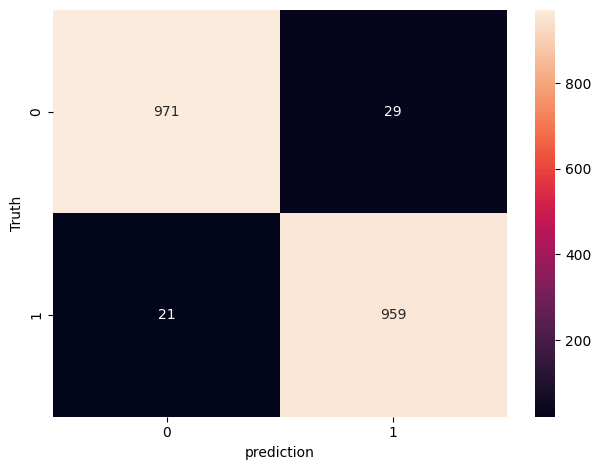

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

from matplotlib import pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("prediction")
plt.ylabel("Truth")
plt.tight_layout()
plt.show()